<a href="https://colab.research.google.com/github/araoclaudio2-create/Assignment-AI-2/blob/main/Assignment_6_Into_to_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


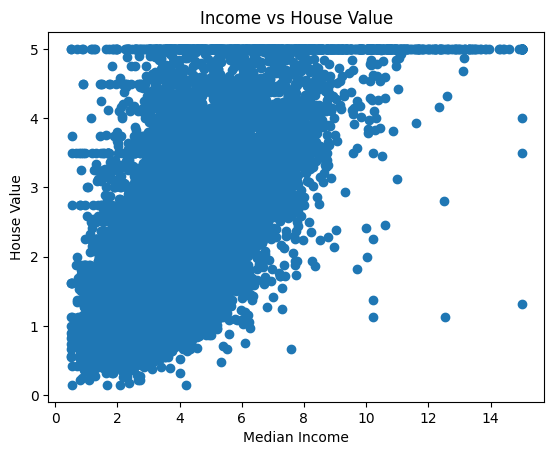

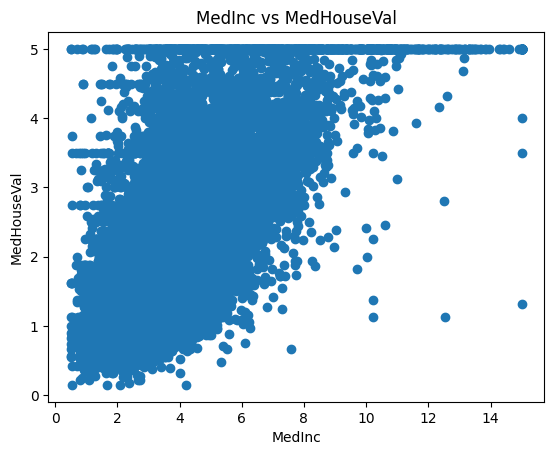

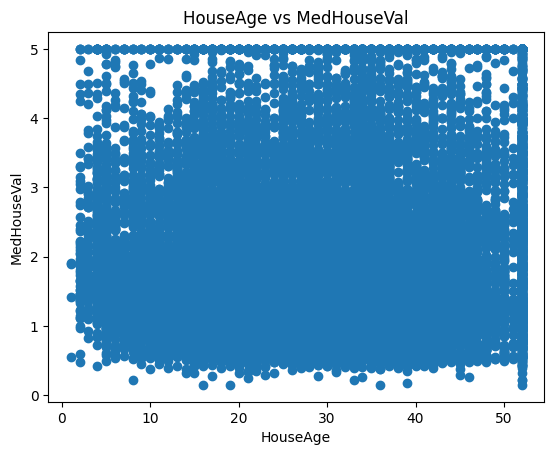

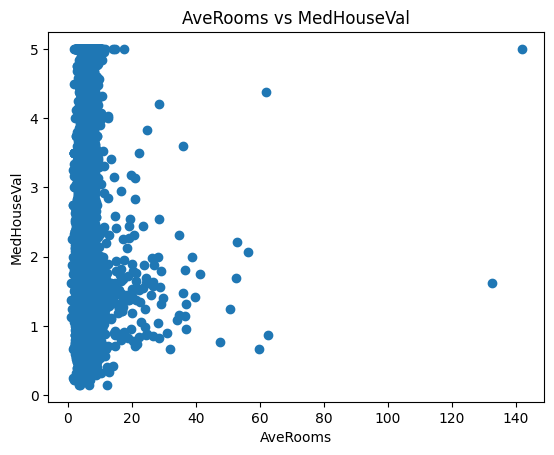

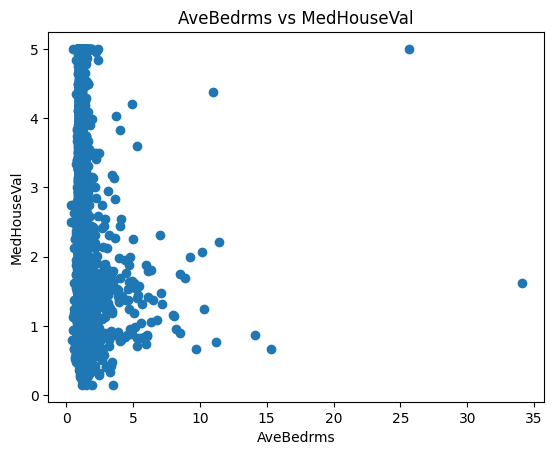

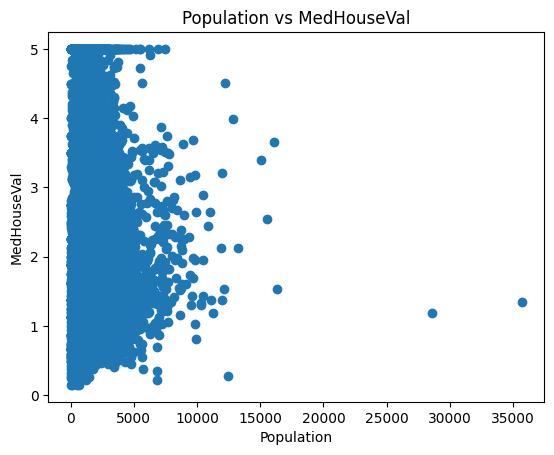

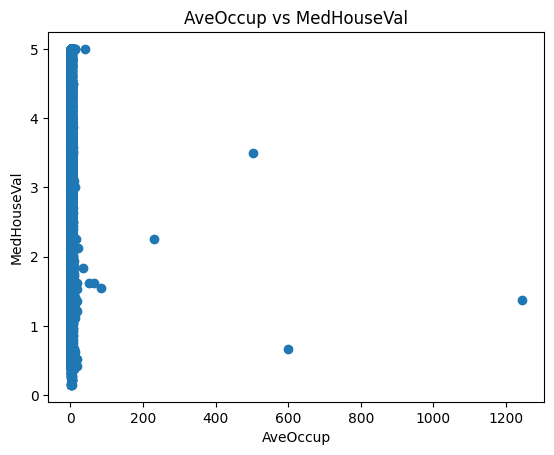

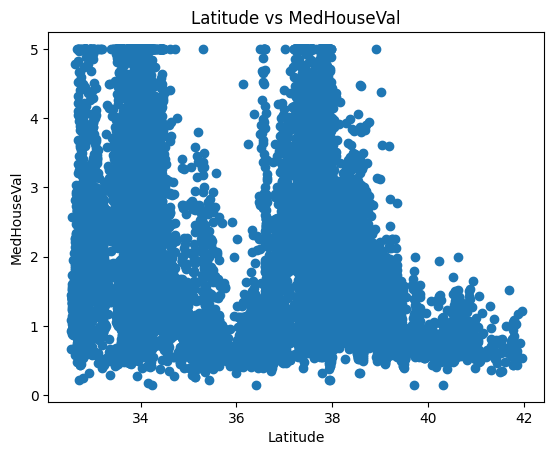

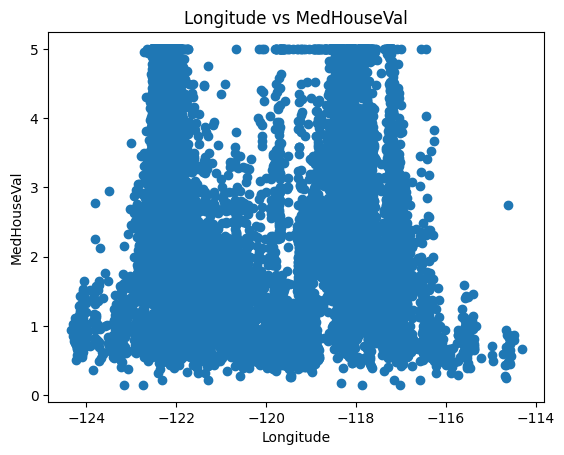

RMSE: 0.7455813830127764
R2 Score: 0.5757877060324508
Predicted House Value: 3.6972308515557373


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import fetch_california_housing

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df['MedHouseVal'] = housing.target

# Show first rows
df.head()

# Check structure
df.info()

# Summary stats
df.describe()

# Check columns
df.columns

df.isnull().sum()

plt.scatter(df['MedInc'], df['MedHouseVal'])
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.title('Income vs House Value')
plt.show()

def plot_feature_vs_target(df, target):
    for col in df.columns:
        if col != target:
            plt.scatter(df[col], df[target])
            plt.xlabel(col)
            plt.ylabel(target)
            plt.title(f"{col} vs {target}")
            plt.show()

plot_feature_vs_target(df, 'MedHouseVal')

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2 Score
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

# Example new data (must match feature order)
new_data = [[8.0, 20, 6, 1, 300, 3, 34, -118]]

prediction = model.predict(new_data)

print("Predicted House Value:", prediction[0])